In [1]:
import json
import os
import pickle as pkl

import dimod
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from dimod import BinaryQuadraticModel, ExactSolver
from dwave.samplers import SimulatedAnnealingSampler
from dwave.system import DWaveSampler, EmbeddingComposite
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import DataLoader, TensorDataset

# Net Class

In [2]:
class QuadraticMLP(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_dim: list[int],
        output_dim: int,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        layer_dims = [input_dim, *hidden_dim, output_dim]
        modules = []
        for index in range(len(layer_dims) - 1):
            modules.append(nn.Linear(layer_dims[index], layer_dims[index + 1]))
            if index < len(layer_dims) - 2:
                modules.append(nn.Tanh())

        self.network = nn.Sequential(*modules)

    def forward(self, 
                x: torch.Tensor,
    ) -> torch.Tensor:
        return self.network(x)

# Loading sample Iris data for training

In [3]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.FloatTensor(X)
y = torch.LongTensor(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [4]:
training_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(training_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Training samples: {len(training_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 105
Test samples: 45


# Optimizer

In [ ]:
class QuadraticAnnealingOptimizer:

    def __init__(
        self,
        sampler,
        model: nn.Module,
        device: str = "cpu",
        subset_size: int = 12,
        step_size: float = 0.05,
        num_reads: int = 100,
        selection: str = "topk",
    ):
        self.sampler = sampler
        self.model = model
        self.device = torch.device(device)
        self.subset_size = subset_size
        self.step_size = step_size
        self.num_reads = num_reads
        self.selection = selection

    def _selected_indices(self, grad_vec: torch.Tensor) -> torch.Tensor:
        block_size = min(self.subset_size, grad_vec.numel())
        if self.selection == "topk":
            return torch.topk(grad_vec.abs(), k=block_size).indices
        if self.selection == "random":
            return torch.randperm(grad_vec.numel(), device=grad_vec.device)[:block_size]
        raise ValueError("selection must be either 'topk' or 'random'")

    def quadratic_model(self, 
                        loss: torch.Tensor,
    ) -> list[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        params = [param for param in self.model.parameters() if param.requires_grad]
        grads = torch.autograd.grad(loss, params, create_graph=True)
        grad_vec = parameters_to_vector(grads)
        selected_indices = self._selected_indices(grad_vec)
        grad_block = grad_vec[selected_indices]

        hessian_block = torch.zeros(
            (selected_indices.numel(), selected_indices.numel()),
            device=self.device,
        )

        for row_index, param_index in enumerate(selected_indices):
            second_grads = torch.autograd.grad(
                grad_vec[param_index],
                params,
                retain_graph=row_index + 1 < selected_indices.numel(),
            )
            second_vec = parameters_to_vector(second_grads)
            hessian_block[row_index] = second_vec[selected_indices]

        hessian_block = 0.5 * (hessian_block + hessian_block.T) # Hermitization
        return (grad_vec.detach(), 
                selected_indices.detach(), 
                grad_block.detach(), 
                hessian_block.detach(),
                )

    def build_bqm(
        self,
        selected_indices: torch.Tensor,
        grad_block: torch.Tensor,
        hessian_block: torch.Tensor,
    ) -> BinaryQuadraticModel:
        step_sq = self.step_size ** 2
        linear = {}
        quadratic = {}
        offset = 0.0

        for local_index, global_index in enumerate(selected_indices.tolist()):
            gradient_value = float(grad_block[local_index].item())
            curvature_value = float(hessian_block[local_index, local_index].item())
            linear[int(global_index)] = 2.0 * self.step_size * gradient_value
            offset += -self.step_size * gradient_value
            offset += 0.5 * step_sq * curvature_value

        for left in range(selected_indices.numel()):
            for right in range(left + 1, selected_indices.numel()):
                coupling = float(hessian_block[left, right].item())
                if abs(coupling) < 1e-12:
                    continue

                left_index = int(selected_indices[left].item())
                right_index = int(selected_indices[right].item())
                linear[left_index] = linear.get(left_index, 0.0) - 2.0 * step_sq * coupling
                linear[right_index] = linear.get(right_index, 0.0) - 2.0 * step_sq * coupling
                quadratic[(left_index, right_index)] = 4.0 * step_sq * coupling
                offset += step_sq * coupling

        return BinaryQuadraticModel(linear, quadratic, offset, dimod.BINARY)

    def sample_bqm(self, 
                   bqm: BinaryQuadraticModel,
    ) -> dimod.SampleSet:
        if isinstance(self.sampler, ExactSolver):
            return self.sampler.sample(bqm)
        return self.sampler.sample(bqm, num_reads=self.num_reads)

    def step(self, 
             features: torch.Tensor, 
             targets: torch.Tensor, 
             loss_fn: nn.Module,
    ) -> dict[str, float | bool | int]:
        self.model.zero_grad(set_to_none=True)
        logits = self.model(features)
        loss = loss_fn(logits, targets)

        current_params = parameters_to_vector(self.model.parameters()).detach().clone()
        _, selected_indices, grad_block, hessian_block = self.quadratic_model(loss)
        bqm = self.build_bqm(selected_indices, grad_block, hessian_block)
        response = self.sample_bqm(bqm)

        delta = torch.zeros_like(current_params)
        for parameter_index in selected_indices.tolist():
            bit_value = response.first.sample[int(parameter_index)]
            delta[int(parameter_index)] = self.step_size if bit_value else -self.step_size

        with torch.no_grad():
            candidate_params = current_params + delta.to(current_params.device)
            vector_to_parameters(candidate_params, self.model.parameters())
            candidate_loss = float(loss_fn(self.model(features), targets).item())

            if candidate_loss > float(loss.item()):
                vector_to_parameters(current_params, self.model.parameters())
                accepted = False
                effective_loss = float(loss.item())
            else:
                accepted = True
                effective_loss = candidate_loss

        return {
            "loss": effective_loss,
            "quadratic_energy": float(response.first.energy),
            "accepted": accepted,
            "selected_variables": int(selected_indices.numel()),
        }

# Training

In [11]:
loss_fn = nn.CrossEntropyLoss()
model = QuadraticMLP(4, [8, 4], 3)
classical_device = "cpu" # TODO: Ogranąc dlaczgo cuda nie działa 

def build_sampler(mode: str = "simulated"):
    normalized_mode = mode.lower()

    if normalized_mode == "dwave":
        try:
            return EmbeddingComposite(DWaveSampler()), "dwave"
        except Exception as exc:
            print(f"Falling back to simulated annealing because the QPU is unavailable: {exc}")
            return SimulatedAnnealingSampler(), "simulated"

    if normalized_mode == "exact":
        return ExactSolver(), "exact"

    if normalized_mode == "simulated":
        return SimulatedAnnealingSampler(), "simulated"

    raise ValueError("mode must be one of: simulated, exact, dwave")

sampler, sampler_name = build_sampler(mode="simulated")
print(f"Using sampler: {sampler_name}")

Using sampler: simulated


In [12]:
def evaluate(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
    ):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)
            targets = targets.to(device)
            logits = model(features)
            total_loss += float(loss_fn(logits, targets).item()) * targets.size(0)
            total_correct += int((logits.argmax(dim=1) == targets).sum().item())
            total_examples += int(targets.size(0))

    average_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return average_loss, accuracy

In [13]:
def train_dwave(
    model: QuadraticMLP,
    train_loader: DataLoader,
    test_loader: DataLoader,
    loss_fn: nn.Module,
    c_device: str,
    sampler,
    epochs: int,
    subset_size: int = 12,
    step_size: float = 0.05,
    num_reads: int = 100,
    ):
    device = torch.device(c_device)
    model.to(device)

    annealer = QuadraticAnnealingOptimizer(
        sampler=sampler,
        model=model,
        device=device,
        subset_size=subset_size,
        step_size=step_size,
        num_reads=num_reads,
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_quadratic_energy": [],
        "acceptance_rate": [],
        "test_loss": [],
        "test_accuracy": [],
    }

    os.makedirs("models", exist_ok=True)
    os.makedirs("stats", exist_ok=True)

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        batch_energies = []
        accepted_steps = 0

        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)
            step_info = annealer.step(features, targets, loss_fn)
            batch_losses.append(step_info["loss"])
            batch_energies.append(step_info["quadratic_energy"])
            accepted_steps += int(step_info["accepted"])

        train_loss, train_accuracy = evaluate(model, train_loader, loss_fn, device)
        test_loss, test_accuracy = evaluate(model, test_loader, loss_fn, device)
        acceptance_rate = accepted_steps / len(train_loader)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["train_quadratic_energy"].append(sum(batch_energies) / len(batch_energies))
        history["acceptance_rate"].append(acceptance_rate)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_accuracy)

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_accuracy:.3f} | "
                f"test_loss={test_loss:.4f} | "
                f"test_acc={test_accuracy:.3f} | "
                f"acceptance={acceptance_rate:.2f}"
            )

    torch.save(model.state_dict(), "models/quadratic_mlp_annealer_state_dict.pth")
    with open("models/config.json", "w") as file:
        json.dump(
            {
                "input_dim": model.input_dim,
                "hidden_dim": model.hidden_dim,
                "output_dim": model.output_dim,
                "sampler": sampler_name,
                "subset_size": subset_size,
                "step_size": step_size,
                "num_reads": num_reads,
                "epochs": epochs,
            },
            file,
            indent=2,
        )

    for stat_name, values in history.items():
        with open(f"stats/{stat_name}.pkl", "wb") as file:
            pkl.dump(values, file)

    return history

In [14]:
history = train_dwave(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    c_device=classical_device,
    sampler=sampler,
    epochs=30,
    subset_size=12,
    step_size=0.05,
    num_reads=200,
    )

Epoch 000 | train_loss=0.7074 | train_acc=0.771 | test_loss=0.7200 | test_acc=0.711 | acceptance=1.00
Epoch 005 | train_loss=0.1886 | train_acc=0.981 | test_loss=0.2496 | test_acc=0.911 | acceptance=1.00
Epoch 010 | train_loss=0.0705 | train_acc=0.971 | test_loss=0.1247 | test_acc=0.956 | acceptance=1.00
Epoch 015 | train_loss=0.0421 | train_acc=0.990 | test_loss=0.1406 | test_acc=0.956 | acceptance=1.00
Epoch 020 | train_loss=0.0718 | train_acc=0.981 | test_loss=0.0810 | test_acc=0.956 | acceptance=1.00
Epoch 025 | train_loss=0.0295 | train_acc=0.990 | test_loss=0.1316 | test_acc=0.978 | acceptance=1.00
Epoch 029 | train_loss=0.0455 | train_acc=0.971 | test_loss=0.2368 | test_acc=0.956 | acceptance=1.00


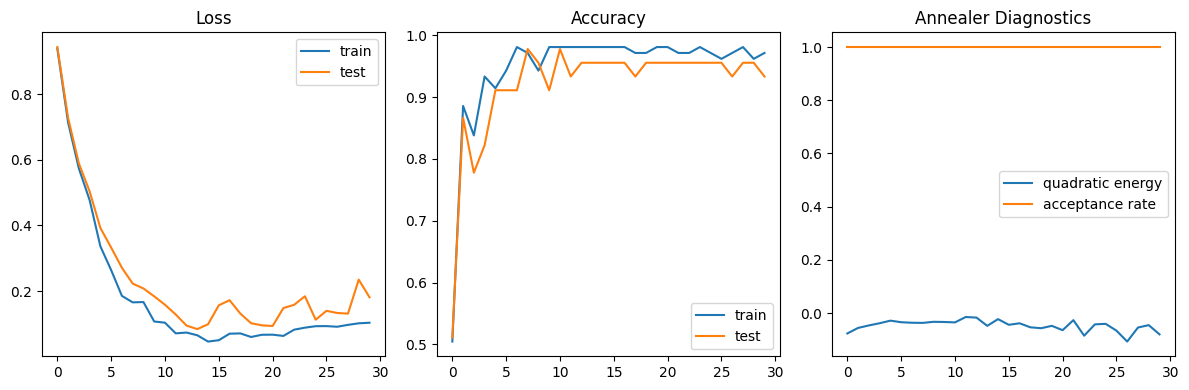

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_accuracy"], label="train")
plt.plot(history["test_accuracy"], label="test")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_quadratic_energy"], label="quadratic energy")
plt.plot(history["acceptance_rate"], label="acceptance rate")
plt.title("Annealer Diagnostics")
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
print(f"Final train accuracy: {history['train_accuracy'][-1]:.3f}")
print(f"Final test accuracy: {history['test_accuracy'][-1]:.3f}")
print(f"Final acceptance rate: {history['acceptance_rate'][-1]:.2f}")

Final train accuracy: 0.971
Final test accuracy: 0.933
Final acceptance rate: 1.00
